In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import json

In [2]:
with open ('alcohol_consumption.json', 'r', encoding='utf-8') as f:
    data = json.load(f)
df = pd.DataFrame(data)
print(df.head())

  ParentLocationCode SpatialDim Dim1 Value  NumericValue  \
0                EUR        LUX  NaN    No           NaN   
1                AFR        SWZ  NaN    No           NaN   
2                WPR        VNM  NaN    No           NaN   
3                EUR        HUN  NaN   Yes           NaN   
4                EMR        JOR  NaN   Yes           NaN   

                        Date    IndicatorCode  
0  2018-03-13T09:44:59+01:00  NCD_CCS_AlcPlan  
1  2022-04-25T15:22:08+02:00  NCD_CCS_AlcPlan  
2  2015-06-12T12:48:55+02:00  NCD_CCS_AlcPlan  
3  2016-08-16T12:47:27+02:00  NCD_CCS_AlcPlan  
4  2015-06-12T12:48:37+02:00  NCD_CCS_AlcPlan  


In [3]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 297817 entries, 0 to 297816
Data columns (total 7 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   ParentLocationCode  295601 non-null  str    
 1   SpatialDim          297817 non-null  str    
 2   Dim1                267872 non-null  str    
 3   Value               296252 non-null  str    
 4   NumericValue        238513 non-null  float64
 5   Date                297817 non-null  str    
 6   IndicatorCode       297817 non-null  str    
dtypes: float64(1), str(6)
memory usage: 15.9 MB


,NumericValue
count,2.385130e+05
mean,1.122240e+03
std,9.034247e+04
min,-2.058835e+01
25%,1.763438e+00
50%,1.091499e+01
75%,3.869449e+01
max,2.381957e+07


In [4]:
df['NumericValue'].isnull().sum()

np.int64(59304)

In [5]:
# remove null value
print(len(df))
df=df.dropna(subset=['NumericValue'])
print(len(df))
print(df["NumericValue"].isnull().sum())

297817
238513
0


In [6]:
# #remove indicators that not relevant
unrelated = set(['RSUD_1', 'RSUD_3', 'RSUD_44', 'RSUD_5'])
df = df[~df['IndicatorCode'].isin(unrelated)]

In [7]:
indicators = df['IndicatorCode'].unique().tolist()
print(indicators)

['SA_0000001398', 'SA_0000001400', 'SA_0000001401', 'SA_0000001403', 'SA_0000001404', 'SA_0000001405', 'SA_0000001406', 'SA_0000001409', 'SA_0000001411', 'SA_0000001413', 'SA_0000001414', 'SA_0000001416', 'SA_0000001418', 'SA_0000001437', 'SA_0000001456', 'SA_0000001457_AA', 'SA_0000001459_AA', 'SA_0000001466', 'SA_0000001470', 'SA_0000001472', 'SA_0000001473', 'SA_0000001474', 'SA_0000001475', 'SA_0000001476', 'SA_0000001477', 'SA_0000001519', 'SA_0000001546', 'SA_0000001688', 'SA_0000001696', 'SA_0000001707', 'SA_0000001711', 'SA_0000001737', 'SA_0000001739', 'SA_0000001741', 'SA_0000001742', 'SA_0000001743', 'SA_0000001745', 'SA_0000001746', 'SA_0000001747', 'SA_0000001748', 'SA_0000001749', 'SA_0000001751', 'SA_0000001752', 'SA_0000001760', 'SA_0000001781', 'SA_0000001783', 'SA_0000001788', 'SA_0000001807_AA', 'SA_0000001808', 'SA_0000001818', 'SA_0000001819', 'SA_0000001820', 'SA_0000001821', 'SA_0000001822', 'SA_0000001823', 'SA_0000001832', 'SA_0000001833', 'SA_0000001834', 'SA_

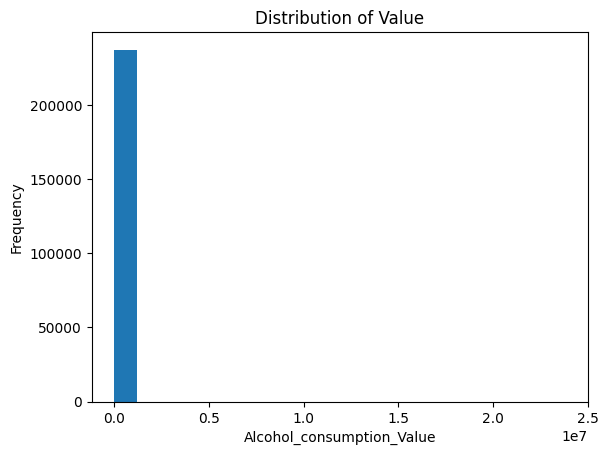

In [8]:
plt.figure()
plt.hist(df["NumericValue"], bins=20)
plt.xlabel("Alcohol_consumption_Value")
plt.ylabel("Frequency")
plt.title("Distribution of Value")
plt.show()


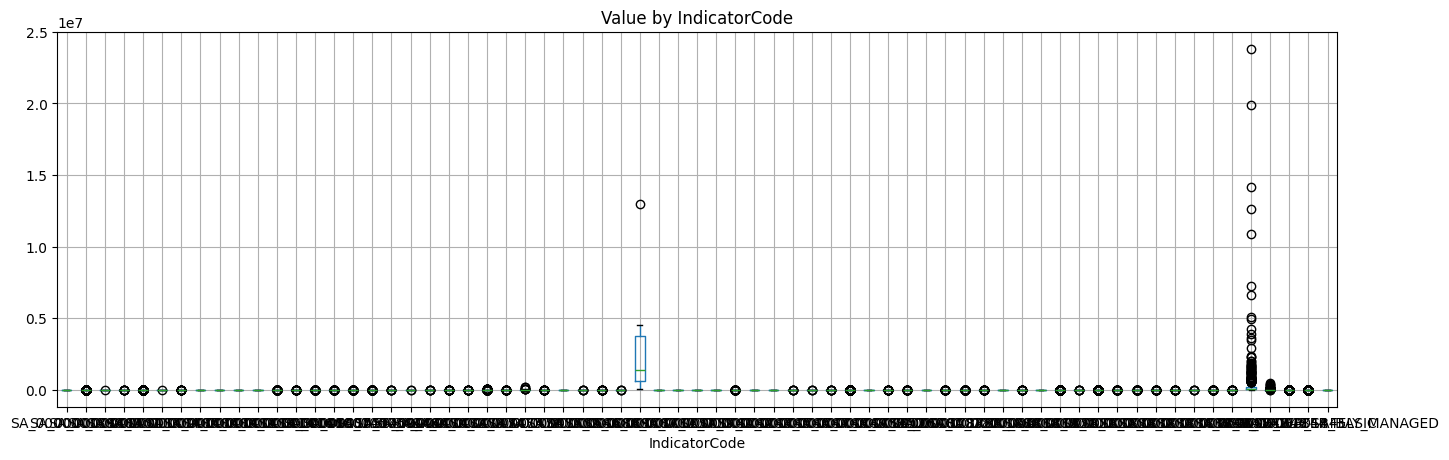

In [9]:
fig, ax = plt.subplots(figsize=(16,5))
df.boxplot(column="NumericValue", by="IndicatorCode", ax=ax)

ax.set_title("Value by IndicatorCode")
plt.suptitle("")
plt.show()